# 数据集划分可视化
验证两个数据集的 train/val/test 划分是否正确（60/20/20）。

In [7]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

DATA_DIR = os.path.join("..", "data")
TRAIN_RATIO, VAL_RATIO = 0.6, 0.2

plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

In [8]:
def load_clean(path):
    d = sio.loadmat(path)
    return np.asarray(d["clean_data"]).reshape(-1).astype(np.float64)

def load_m905(path):
    with h5py.File(path, "r") as f:
        ds = f["data"]
        assert isinstance(ds, h5py.Dataset)
        return np.asarray(ds[...]).reshape(-1).astype(np.float64)

def split_indices(n, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    t = int(train_ratio * n)
    v = int(val_ratio * n)
    return t, t + v

def normalize(sig):
    return (sig - sig.min()) / (sig.max() - sig.min())

In [9]:
raw_clean = load_clean(os.path.join(DATA_DIR, "fft_decomposition_cleaned.mat"))
raw_m905  = load_m905 (os.path.join(DATA_DIR, "matlab905(1).mat"))

print(f"fft_decomposition_cleaned : {len(raw_clean):,} samples")
print(f"matlab905(1)              : {len(raw_m905):,} samples")

fft_decomposition_cleaned : 993,537 samples
matlab905(1)              : 979,514 samples


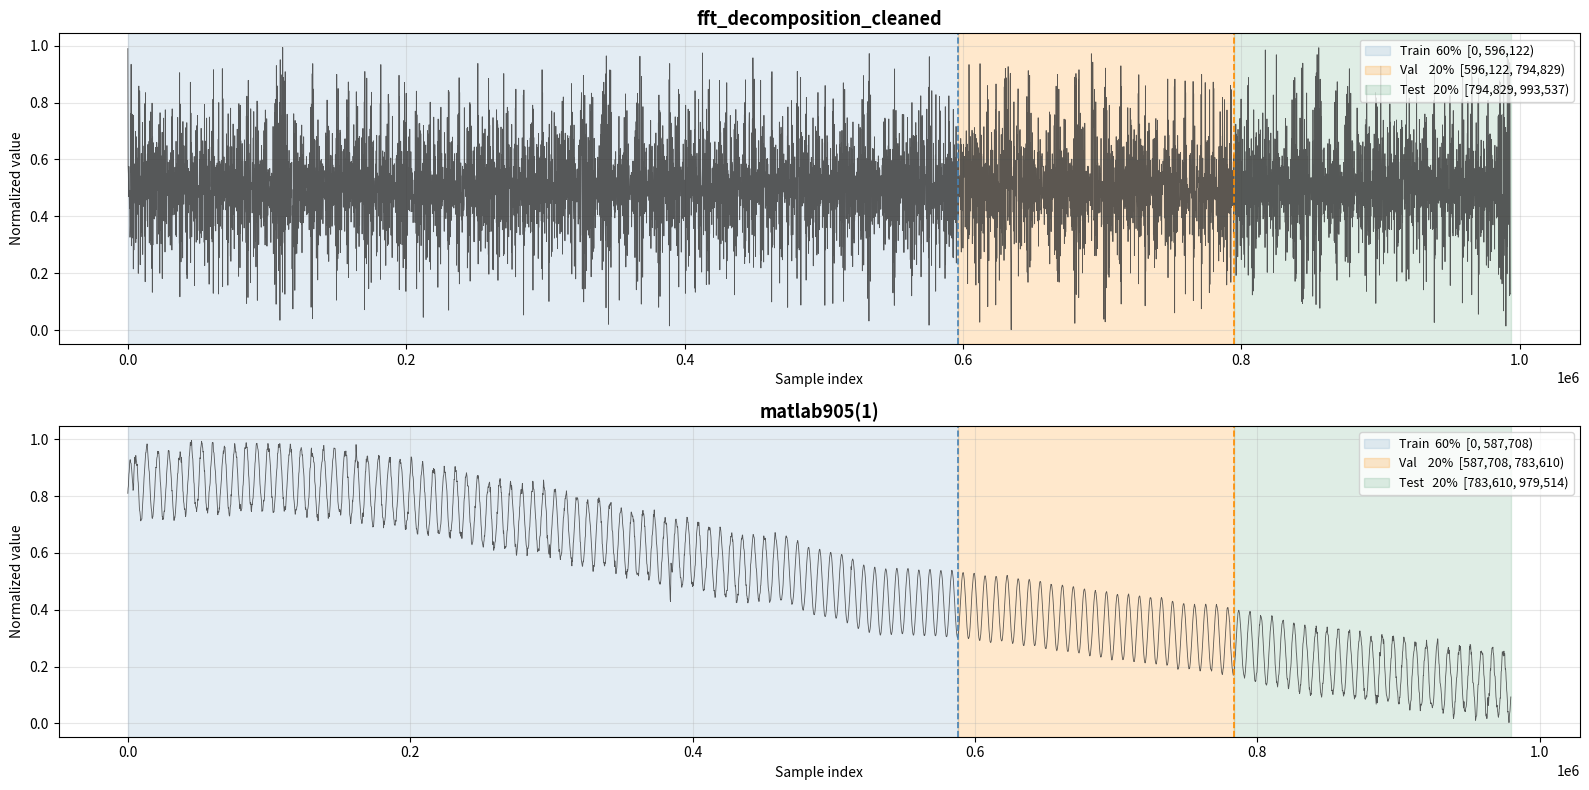

In [10]:
def plot_split(sig, title, ax, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, downsample=5000):
    n = len(sig)
    t_end, v_end = split_indices(n, train_ratio, val_ratio)
    sig_norm = normalize(sig)

    step = max(1, n // downsample)
    idx = np.arange(n)[::step]

    ax.plot(idx, sig_norm[::step], color="#333", linewidth=0.6, alpha=0.8)
    ax.axvspan(0,      t_end,  alpha=0.15, color="steelblue",  label=f"Train  {train_ratio:.0%}  [0, {t_end:,})")
    ax.axvspan(t_end,  v_end,  alpha=0.20, color="darkorange", label=f"Val    {val_ratio:.0%}  [{t_end:,}, {v_end:,})")
    ax.axvspan(v_end,  n,      alpha=0.15, color="seagreen",   label=f"Test   {1-train_ratio-val_ratio:.0%}  [{v_end:,}, {n:,})")
    ax.axvline(t_end, color="steelblue",  linewidth=1.2, linestyle="--")
    ax.axvline(v_end, color="darkorange", linewidth=1.2, linestyle="--")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Normalized value")
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), tight_layout=True)
plot_split(raw_clean, "fft_decomposition_cleaned", axes[0])
plot_split(raw_m905,  "matlab905(1)",              axes[1])
plt.savefig("split_overview.svg", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
def split_stats(sig, name):
    n = len(sig)
    t_end, v_end = split_indices(n)
    splits = {"train": sig[:t_end], "val": sig[t_end:v_end], "test": sig[v_end:]}
    print(f"\n{'='*50}")
    print(f"{name}  (total {n:,})")
    print(f"{'split':<8} {'samples':>9} {'ratio':>7} {'min':>10} {'max':>10} {'mean':>10} {'std':>10}")
    print("-" * 68)
    for sname, seg in splits.items():
        print(f"{sname:<8} {len(seg):>9,} {len(seg)/n:>7.1%} "
              f"{seg.min():>10.4f} {seg.max():>10.4f} "
              f"{seg.mean():>10.4f} {seg.std():>10.4f}")

split_stats(raw_clean, "fft_decomposition_cleaned")
split_stats(raw_m905,  "matlab905(1)")


fft_decomposition_cleaned  (total 993,537)
split      samples   ratio        min        max       mean        std
--------------------------------------------------------------------
train      596,122   60.0%    -0.1344     0.1332     0.0002     0.0439
val        198,707   20.0%    -0.1343     0.1332     0.0003     0.0444
test       198,708   20.0%    -0.1343     0.1332     0.0000     0.0454

matlab905(1)  (total 979,514)
split      samples   ratio        min        max       mean        std
--------------------------------------------------------------------
train      587,708   60.0%   804.2320   827.8193   817.1250     5.8689
val        195,902   20.0%   799.6933   812.0519   805.9738     3.0842
test       195,904   20.0%   794.0465   807.5006   800.7285     3.1508


/tmp/ipykernel_16946/557181508.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_bp, labels=["Train", "Val", "Test"], patch_artist=True)


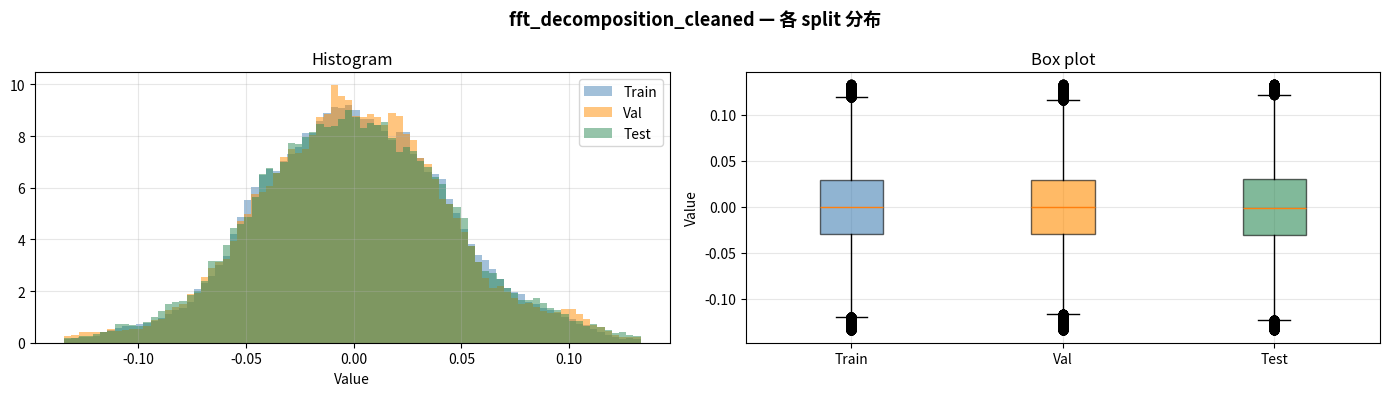

/tmp/ipykernel_16946/557181508.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_bp, labels=["Train", "Val", "Test"], patch_artist=True)


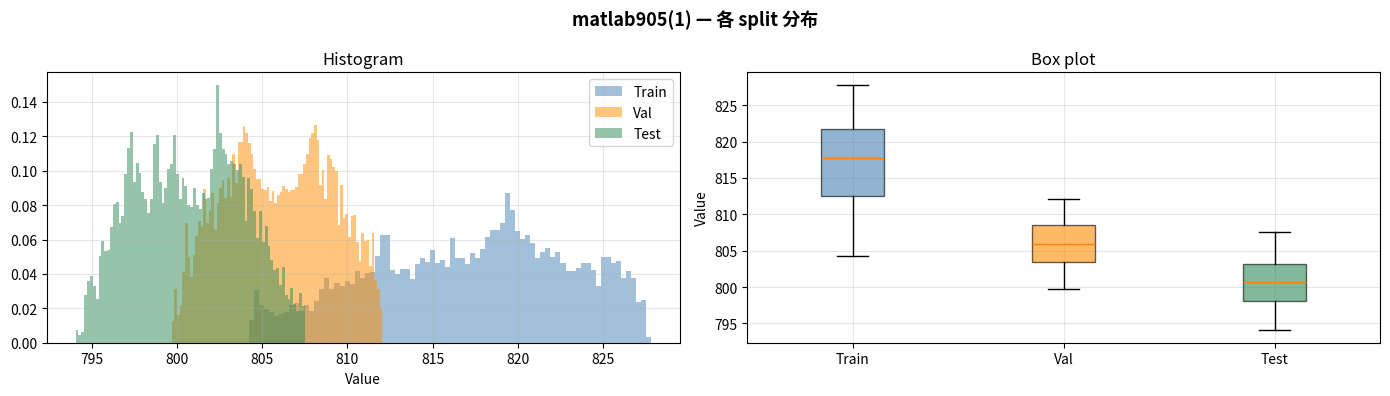

In [12]:
def plot_distributions(sig, name):
    n = len(sig)
    t_end, v_end = split_indices(n)
    splits = {"Train": sig[:t_end], "Val": sig[t_end:v_end], "Test": sig[v_end:]}
    colors = {"Train": "steelblue", "Val": "darkorange", "Test": "seagreen"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
    fig.suptitle(f"{name} — 各 split 分布", fontsize=13, fontweight="bold")

    for sname, seg in splits.items():
        axes[0].hist(seg, bins=80, alpha=0.5, color=colors[sname], label=sname, density=True)
    axes[0].set_title("Histogram")
    axes[0].set_xlabel("Value")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    data_bp = [splits[k] for k in ["Train", "Val", "Test"]]
    bp = axes[1].boxplot(data_bp, labels=["Train", "Val", "Test"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ["steelblue", "darkorange", "seagreen"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[1].set_title("Box plot")
    axes[1].set_ylabel("Value")
    axes[1].grid(True, alpha=0.3)

    plt.savefig(f"dist_{name.replace('(', '').replace(')', '')}.svg", dpi=150, bbox_inches="tight")
    plt.show()

plot_distributions(raw_clean, "fft_decomposition_cleaned")
plot_distributions(raw_m905,  "matlab905(1)")